<img src="https://drive.google.com/uc?id=1aDMlYVXlyWUCMcOXwtZPF77BXAhvZzwM" alt="Alt text" width="700"/>

In this notebook, we'll see how to generate captions out of an image using OpenAI models.

In [2]:
%%capture --no-stderr
%pip install --quiet -U openai gdown

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GEMINI_API_KEY")

GEMINI_API_KEY: ··········


First things first, let’s download a beautiful photo of Bengaluru.

In [4]:
import gdown

# Google Drive file ID
file_id = "1g8ybWMjFVrasbaXPgHG4hD9Er57pL6Cj"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the image
gdown.download(url, output="image.png", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1g8ybWMjFVrasbaXPgHG4hD9Er57pL6Cj
To: /content/image.png
100%|██████████| 173k/173k [00:00<00:00, 50.9MB/s]


'image.png'

Now, load the image using Pillow and make sure it's properly resized before sending it to the LLM.

> This is a very important step!! If you send HD pictures, your token usage will be way bigger!

In [5]:
from PIL import Image

# Open and resize the image
img = Image.open("image.png").convert("RGB")
img_resized = img.resize((512, 512))

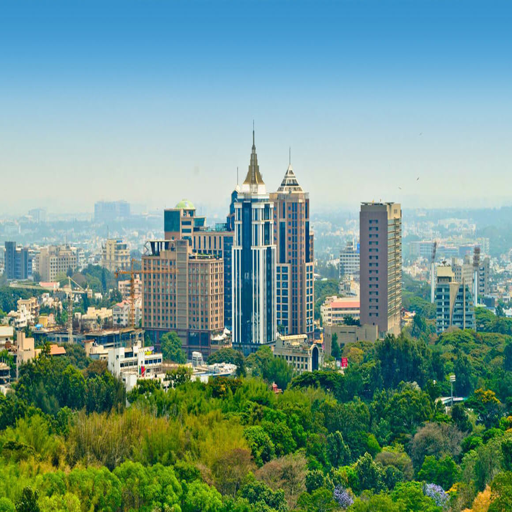

In [6]:
img_resized

We can't send the images as-is—first, we need to encode them using base64.

In [7]:
import base64
from io import BytesIO

def encode_image(image: Image.Image) -> str:
    buffered = BytesIO()
    image.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode()


base64_image = encode_image(img_resized)

Finally, let's call the model.

In [8]:
# from openai import OpenAI

# client = OpenAI()

# chat_completion = client.chat.completions.create(
#     messages=[
#         {
#             "role": "user",
#             "content": [
#                 {
#                     "type": "text",
#                     "text": "Describe what you see in the picture",
#                 },
#                 {
#                     "type": "image_url",
#                     "image_url": {
#                         "url": f"data:image/jpeg;base64,{base64_image}",
#                     },
#                 },
#             ],
#         }
#     ],
#     model="gpt-4o",
# )

In [13]:
import google.generativeai as genai

for model in genai.list_models():
  print(model.name, model.description)

models/embedding-gecko-001 Obtain a distributed representation of a text.
models/gemini-2.5-pro-preview-03-25 Gemini 2.5 Pro Preview 03-25
models/gemini-2.5-flash-preview-05-20 Preview release (April 17th, 2025) of Gemini 2.5 Flash
models/gemini-2.5-flash Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.
models/gemini-2.5-flash-lite-preview-06-17 Preview release (June 11th, 2025) of Gemini 2.5 Flash-Lite
models/gemini-2.5-pro-preview-05-06 Preview release (May 6th, 2025) of Gemini 2.5 Pro
models/gemini-2.5-pro-preview-06-05 Preview release (June 5th, 2025) of Gemini 2.5 Pro
models/gemini-2.5-pro Stable release (June 17th, 2025) of Gemini 2.5 Pro
models/gemini-2.0-flash-exp Gemini 2.0 Flash Experimental
models/gemini-2.0-flash Gemini 2.0 Flash
models/gemini-2.0-flash-001 Stable version of Gemini 2.0 Flash, our fast and versatile multimodal model for scaling across diverse tasks, released in January of 2025.


In [14]:

# Make sure to add your GOOGLE_API_KEY to the Colab secrets manager
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
genai.configure(api_key=GOOGLE_API_KEY)

# Initialize the Generative Model with the vision capabilities
gemini_model = genai.GenerativeModel('gemini-2.0-flash-001')

# Prepare the image data
image_data = {
    'mime_type': 'image/png',
    'data': base64_image
}

# Create the content for the API call
content = [
    {"text": "Describe what you see in the picture"},
    image_data
]

# Generate content
chat_completion = gemini_model.generate_content(content)

In [17]:
print(chat_completion.text)

The image shows a cityscape under a clear blue sky. In the foreground, there's a dense canopy of trees in various shades of green, suggesting a park or a forested area. Behind the trees, a cluster of modern high-rise buildings dominates the view. The buildings have diverse architectural designs, with some featuring sharp spires, while others have more boxy, contemporary looks.

In the distance, the cityscape extends further, appearing somewhat hazy, with other buildings visible on the horizon. The overall impression is that of a vibrant city with a mix of urban development and green spaces.


In [ ]:
# print(chat_completion.choices[0].message.content)
